In [1]:
import networkx as nx
import rustworkx as rx
import igraph as ig

import osmnx as ox
import numpy as np

from pathlib import Path

ox.__version__

'2.1.0'

### Initial state

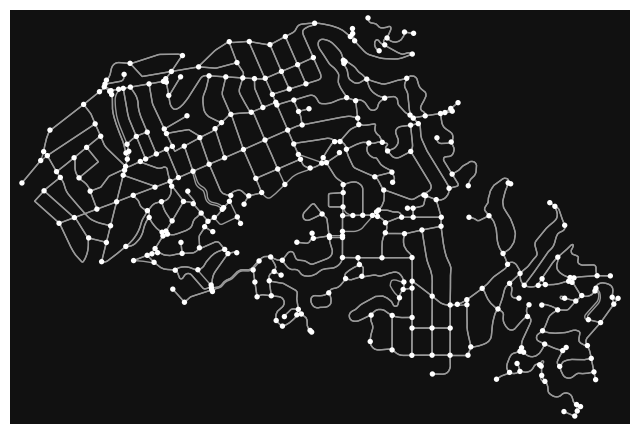

In [2]:
# download/model a street network for some city then visualize it
G = ox.graph.graph_from_place("Piedmont, California, USA", network_type="drive") # (edges : 932, nodes : 349)
# G = ox.graph.graph_from_place("Pessac, France", network_type="drive") # (edges : 4783, nodes : 2102) CRASH
# G = ox.graph.graph_from_place("Nantes, France", network_type="drive") # (edges : 13848, nodes : 6502) CRASH
fig, ax = ox.plot.plot_graph(G)

### Graph preprocessing

In [3]:
for u,v,k in G.edges:
    attrs_e = {(u, v, k): {
        'demand': 0, 
        'weight': 1, 
        'capacity': np.random.randint(5,10)
        # 'capacity': 1

        }
    }
    nx.set_edge_attributes(G, attrs_e)

for u,v,k in G.edges:
    print(G[u][v][k])
    break

{'osmid': 6345781, 'highway': 'residential', 'name': 'Rose Avenue', 'oneway': False, 'reversed': False, 'length': np.float64(230.12441194959652), 'geometry': <LINESTRING (-122.248 37.826, -122.248 37.826, -122.246 37.828)>, 'demand': 0, 'weight': 1, 'capacity': 6}


In [4]:
# NX_G=ox.convert.to_digraph(G) NOT FOR NOW CAUSE WE SET WEIGHTS=1 or 10000
NX_G=nx.DiGraph(G)

In [5]:
for u in NX_G.nodes:
    print(NX_G[u])
    break

{53064327: {'osmid': 6345781, 'highway': 'residential', 'name': 'Rose Avenue', 'oneway': False, 'reversed': False, 'length': np.float64(230.12441194959652), 'geometry': <LINESTRING (-122.248 37.826, -122.248 37.826, -122.246 37.828)>, 'demand': 0, 'weight': 1, 'capacity': 6}, 53075599: {'osmid': 6345781, 'highway': 'residential', 'name': 'Rose Avenue', 'oneway': False, 'reversed': True, 'length': np.float64(122.23491457693369), 'geometry': <LINESTRING (-122.248 37.826, -122.248 37.826, -122.248 37.826, -122.248 37....>, 'demand': 0, 'weight': 1, 'capacity': 9}}


In [6]:
for u,v in NX_G.edges:
    print(NX_G[u][v])
    break

{'osmid': 6345781, 'highway': 'residential', 'name': 'Rose Avenue', 'oneway': False, 'reversed': False, 'length': np.float64(230.12441194959652), 'geometry': <LINESTRING (-122.248 37.826, -122.248 37.826, -122.246 37.828)>, 'demand': 0, 'weight': 1, 'capacity': 6}


In [7]:
NX_G=NX_G.subgraph(max(nx.strongly_connected_components(NX_G), key=len))

In [8]:
RX_G = rx.networkx_converter(NX_G, keep_attributes=True)

In [9]:
IG_G:ig.Graph = ig.Graph.from_networkx(NX_G)

### Nodes mapping

In [10]:
RX_TO_NX={}
for node_id, node in zip(RX_G.node_indices(), RX_G.nodes()):
    RX_TO_NX[node_id] = node['__networkx_node__']
NX_TO_RX = {v:k for k,v in RX_TO_NX.items()}

NX_TO_RX.items(), RX_TO_NX.items()

(dict_items([(53017091, 0), (53018397, 1), (53018399, 2), (53018402, 3), (53018404, 4), (53018410, 5), (53018411, 6), (53021742, 7), (53021743, 8), (53021750, 9), (53022623, 10), (53022625, 11), (53023513, 12), (53025057, 13), (53025060, 14), (53025220, 15), (53025222, 16), (53027454, 17), (53027455, 18), (53027457, 19), (53027459, 20), (53027461, 21), (53027463, 22), (53028190, 23), (53028192, 24), (53033660, 25), (53035699, 26), (53036557, 27), (53036558, 28), (53037306, 29), (53037307, 30), (53040495, 31), (53040794, 32), (53041432, 33), (53041437, 34), (53041440, 35), (53041442, 36), (53041443, 37), (53041445, 38), (53041668, 39), (53041670, 40), (53042706, 41), (53042707, 42), (53044573, 43), (53044575, 44), (53044661, 45), (53044664, 46), (53046249, 47), (53046250, 48), (53046251, 49), (53046252, 50), (53046253, 51), (53046254, 52), (53046255, 53), (53050874, 54), (53050875, 55), (53057697, 56), (53059166, 57), (53059173, 58), (53059175, 59), (53059186, 60), (53059187, 61), (5305

In [11]:
def map_id(d:dict|int, mapping_dict:dict=NX_TO_RX):
    if type(d)==int:
        return mapping_dict[d]
    elif type(d)==dict:
        return {mapping_dict[k]:[[mapping_dict[node] for node in v]] if v is not None else k for k,v in d.items()}
    elif type(d)==list:
        return {mapping_dict[k]:[[mapping_dict[node] for node in v]] if v is not None else k for k,v in enumerate(d)}


### Time NetworkX

In [12]:
%%time
nx_paths={k:dict(v) for k,v in dict(nx.all_pairs_all_shortest_paths(NX_G)).items()}

CPU times: user 5.64 s, sys: 59.2 ms, total: 5.7 s
Wall time: 5.71 s


### TESTS RX

In [13]:
(edge_list:=RX_G.edges())[0]

{'osmid': 6345781,
 'highway': 'residential',
 'name': 'Rose Avenue',
 'oneway': False,
 'reversed': False,
 'length': np.float64(230.12441194959652),
 'geometry': <LINESTRING (-122.248 37.826, -122.248 37.826, -122.246 37.828)>,
 'demand': 0,
 'weight': 1,
 'capacity': 6}

In [14]:
(nodes_list:=RX_G.nodes())[0]

{'y': 37.8262501,
 'x': -122.2476037,
 'street_count': 3,
 '__networkx_node__': 53017091}

In [15]:
RX_G.num_edges(), RX_G.num_nodes()

(932, 349)

### Time IGRAPH

In [16]:
%%time
ig_paths={}
nx_ig_paths={}
for node in range(IG_G.vcount()):
    ig_paths[node] = {k:v for k,v in enumerate(IG_G.get_all_shortest_paths(node))}
    # nx_ig_paths[RX_TO_NX[node]] = {RX_TO_NX[k]:[RX_TO_NX[n] for n in v] for k,v in ig_paths.items()}
# nx_ig_paths.items()
# ig_paths

CPU times: user 1.29 s, sys: 91.7 ms, total: 1.39 s
Wall time: 1.4 s


### Time RX + conversion, NX

In [17]:
%%time
RX_G = rx.networkx_converter(NX_G, keep_attributes=True)
rx_paths={k:dict(v) for k,v in dict(rx.all_pairs_dijkstra_shortest_paths(RX_G, edge_cost_fn=lambda x:1)).items()}
# nx_rx_paths={map_id(k, RX_TO_NX): map_id(v, RX_TO_NX) for k,v in rx_paths.items()}
# for node in nx_rx_paths.keys():
#     nx_rx_paths[node][node]=[[node]]
# nx_rx_paths

CPU times: user 187 ms, sys: 56.9 ms, total: 244 ms
Wall time: 153 ms


In [18]:
def convert_rustworkx_to_networkx(graph:rx.PyGraph | rx.PyDiGraph):
    """Convert a rustworkx PyGraph or PyDiGraph to a networkx graph."""
    edge_list = [(
        graph[x[0]]['__networkx_node__'], graph[x[1]]['__networkx_node__'],
        {'weight': x[2]}) for x in graph.weighted_edge_list()]
    
    if isinstance(graph, rx.PyGraph):
        if graph.multigraph:
            return nx.MultiGraph(edge_list)
        else:
            return nx.Graph(edge_list)
    else:
        if graph.multigraph:
            return nx.MultiDiGraph(edge_list)
        else:
            return nx.DiGraph(edge_list)

In [19]:
G6 = convert_rustworkx_to_networkx(RX_G)

In [20]:
for u,v in G6.edges:
    print(G6[u][v])
    break

{'weight': {'osmid': 6345781, 'highway': 'residential', 'name': 'Rose Avenue', 'oneway': False, 'reversed': False, 'length': np.float64(230.12441194959652), 'geometry': <LINESTRING (-122.248 37.826, -122.248 37.826, -122.246 37.828)>, 'demand': 0, 'weight': 1, 'capacity': 6}}


In [ ]:
ox.plot.plot_graph(nx.MultiDiGraph(G6))